# Preliminary statistical data analysis - Kaggle credit card dataset

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pylab import rcParams
from scipy.stats import shapiro
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import probplot
import kagglehub
import os

In [3]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]), sep=",")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


We can see that ...

## Amount column analysis

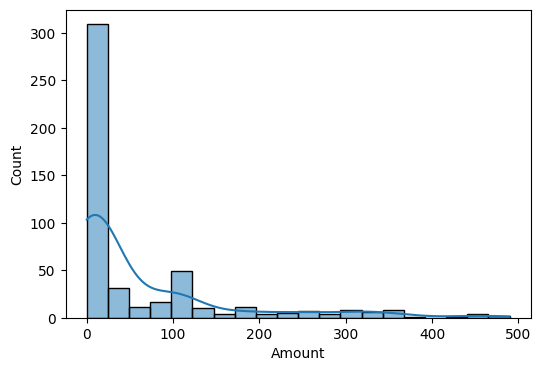

In [30]:
amt = df['Amount']

rcParams['figure.figsize'] = 6, 4

sns.histplot(data=df[df['Class']==1], x="Amount", kde=True)
plt.show()

From the chart, we can conclude that the hypothesis that most fraud occurs with large amounts is not true.

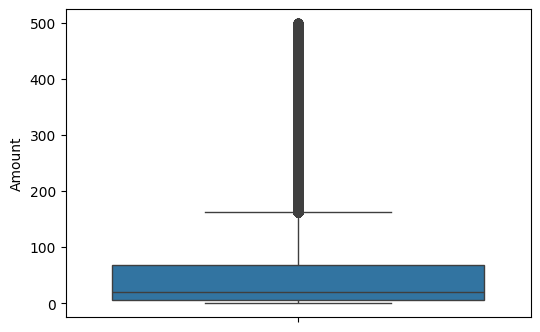

In [9]:
sns.boxplot(df[amt<500]['Amount'], whis=1.5)
plt.show()

In [10]:
df[amt<500]["Class"].value_counts()[1] / df["Class"].value_counts()[1] * 100

np.float64(92.88617886178862)

By cleaning the Amount feature from outliers (taking less than 500), we will be left with 93 percent of fraud observations, which we consider acceptable.

In [11]:
amt_cond = (amt<0.1) | (amt>500)
df[amt_cond]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
51,36.0,-1.004929,-0.985978,-0.038039,3.710061,-6.631951,5.122103,4.371691,-2.006868,-0.278736,...,1.393406,-0.381671,0.969719,0.019445,0.570923,0.333278,0.857373,-0.075538,1402.95,0
89,59.0,-0.773293,-4.146007,-0.932038,0.027094,-1.698307,0.460188,0.737344,-0.314216,-0.842673,...,0.890978,0.026123,-1.134769,-0.654958,0.098386,-0.209150,-0.171709,0.208057,1142.02,0
134,83.0,-1.897331,0.955626,0.052543,1.276656,-3.323084,3.229911,1.029631,1.515607,-0.059627,...,0.128416,0.776078,0.477537,-0.608981,-1.120892,-0.413851,0.061399,-0.187964,552.18,0
140,87.0,-5.101877,1.897022,-3.458034,-1.277543,-5.517758,2.098366,3.329603,1.250966,0.271501,...,-0.871744,-0.678879,-0.555900,-0.761660,0.066611,0.767227,0.731634,-0.860310,919.60,0
150,93.0,-1.640014,-0.479831,1.613630,2.997979,-3.803788,5.051812,3.315254,-0.303785,0.671395,...,-0.367933,0.641891,-0.405779,-1.268700,0.494090,0.610967,0.608993,-0.410034,937.69,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284672,172665.0,-1.107642,1.188691,1.126617,0.191009,-0.748875,1.023729,-1.585121,-1.457420,0.602547,...,2.684859,0.308346,0.258116,-0.548003,-0.493519,-0.628467,0.150129,0.016900,0.01,0
284703,172699.0,1.019594,-1.956473,-1.431268,0.539727,-0.499995,0.301251,0.326079,-0.062475,1.121288,...,-0.081894,-1.202749,-0.182683,-1.075679,-0.417648,-1.080842,-0.049144,0.039078,521.90,0
284712,172704.0,0.470194,-1.619056,-2.258427,4.440719,0.202024,-0.458243,1.970565,-0.665303,-1.630737,...,0.603016,0.104952,-0.716836,0.121688,0.170587,0.082567,-0.218942,0.070955,787.95,0
284732,172721.0,1.076175,-3.116353,-2.051439,-0.953189,-1.544838,-1.124645,0.385570,-0.698014,-1.829401,...,0.104853,-0.598243,-0.343164,0.088299,-0.267658,-0.313651,-0.132091,0.056029,664.60,0


In [12]:
df.loc[amt_cond, 'Amount'] = amt.median()

/tmp/ipykernel_18883/767393185.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(amt, bins=20)


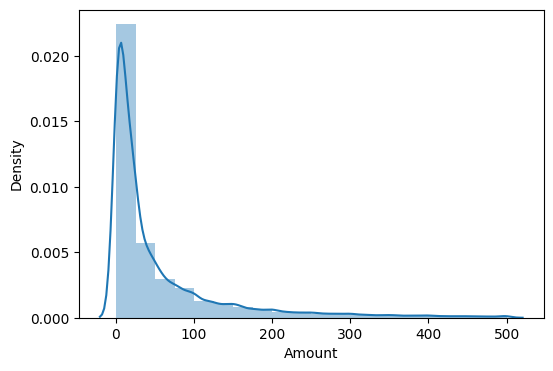

In [36]:
sns.distplot(amt, bins=20)
plt.show()

## Analysis of other features

In [14]:
NO_TARGET_FEATURES_TRAIN = df.drop(columns=['Class', 'Amount'])
NO_TARGET_FEATURES_TRAIN.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752


Distribution analysis

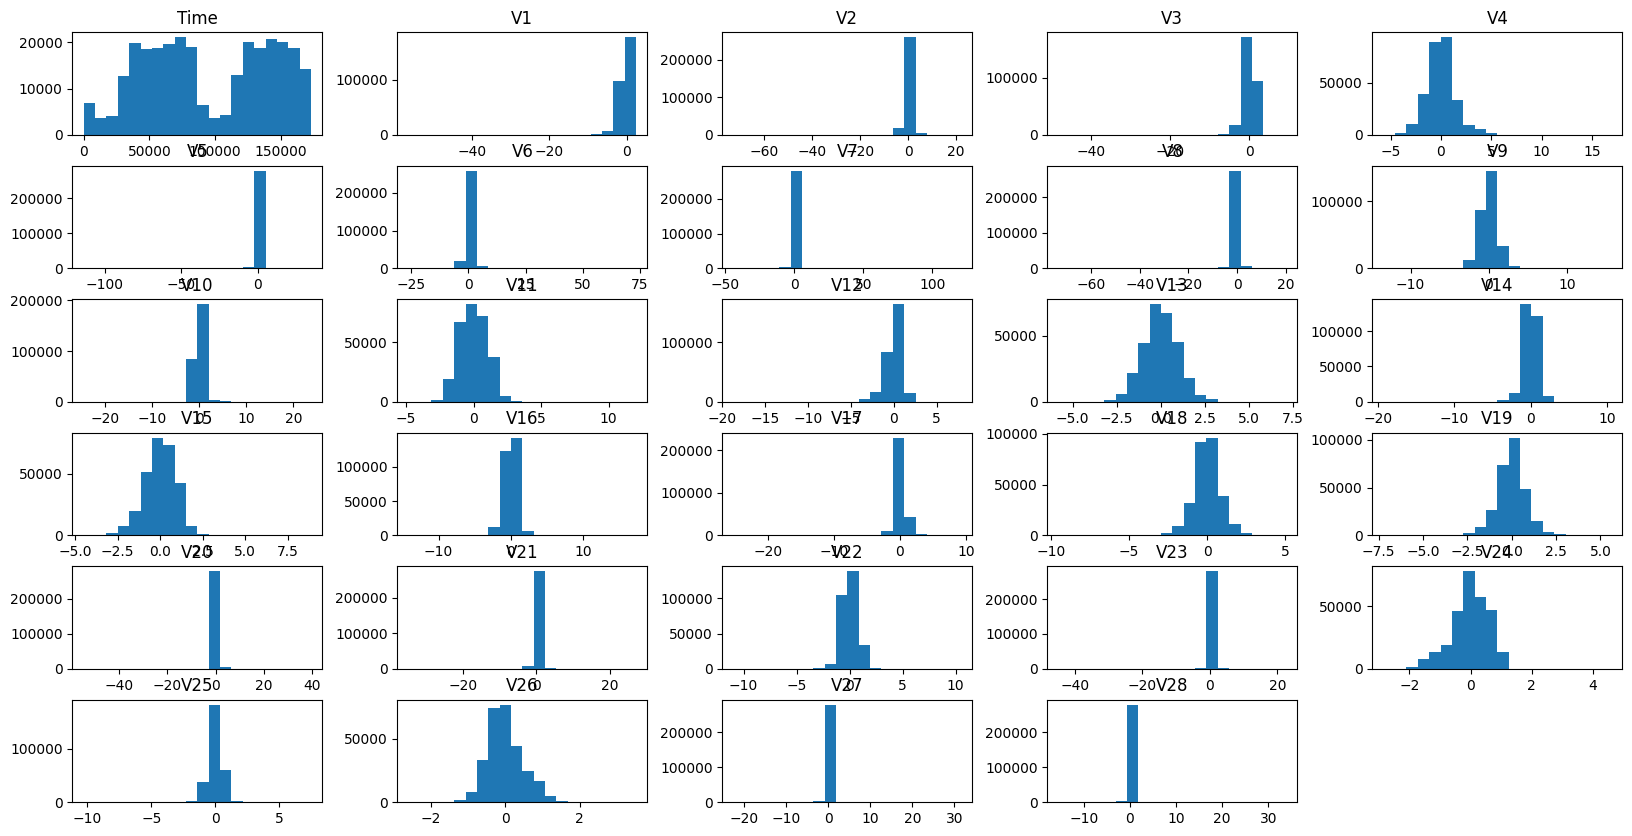

In [15]:
rcParams['figure.figsize'] = 20, 10

NO_TARGET_FEATURES_TRAIN.hist(bins=20, grid=False)
plt.show()

The idea is to make data follow normal distribution. For that, we can apply outliers handling.

In [16]:
class DataPreprocessing():

  # This class is handling empty data, filling by medians.

  def __init__(self):
    self.nans = None
    self.medians_nan = None
    self.median_amount  = None


  def fit(self, X):
    self.nans = X.columns[X.isna().any()].tolist()
    self.medians_nan = X[self.nans].median()
    self.median_amount = X["Amount"].median()


  def transform(self, X):
    X = X.copy()

    if self.nans:
      X[self.nans] = X[self.nans].fillna(self.medians_nan)

    return X

In [17]:
def boxplot_bounds(series, whis=1.5):
  # Calculate 1 and 3 quartiles and find the range, out of which is considered outlier.
  # If outlier, it will be replaced by median.

  s = series.dropna()
  q1 = s.quantile(0.25)
  q3 = s.quantile(0.75)
  iqr = q3 - q1
  low = q1 - whis * iqr
  high = q3 + whis * iqr
  return low, high

def apply_bounds(df, f, low, high, fill):
  df = df.copy()
  mask = (df[f] < low) | (df[f] > high)
  df.loc[mask, f] = fill
  return df

In [18]:
preprocessor = DataPreprocessing()
preprocessor.fit(df)
df_transformed = preprocessor.transform(df)


NO_TARGET_NAMES = NO_TARGET_FEATURES_TRAIN.columns.tolist()
bounds = {}
fills = {}

for f in NO_TARGET_NAMES:
  low, high = boxplot_bounds(df_transformed[f], whis=1.5)
  bounds[f] = (low, high)
  fills[f] = df_transformed[f].median()

for f in NO_TARGET_NAMES:
  low, high = bounds[f]
  fill = fills[f]
  df_transformed = apply_bounds(df_transformed, f, low, high, fill)

After handling outliers and missing data, let's plot distribution charts.

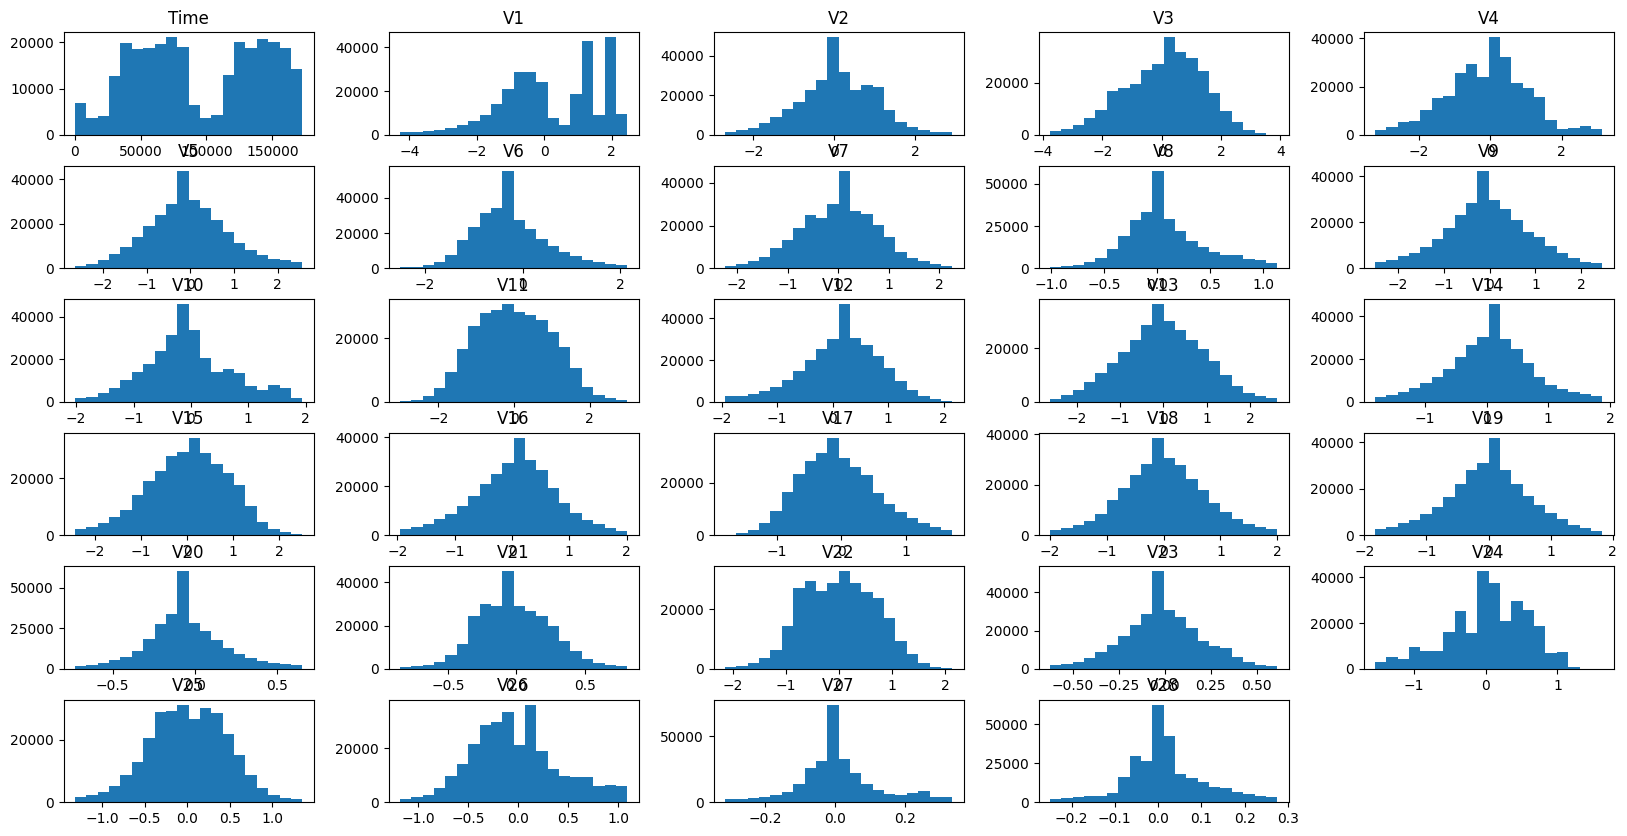

In [19]:
rcParams['figure.figsize'] = 20, 10

df_transformed[NO_TARGET_NAMES].hist(bins=20, grid=False)
plt.show()

- Now distribution looks much more "normal". We can apply these rules in the preprocessing of data.   
- Attention, we will split data into test and train sets and use median and bounds of train set to fill the test data samples to avoid data leakage.

## Correlation analysis

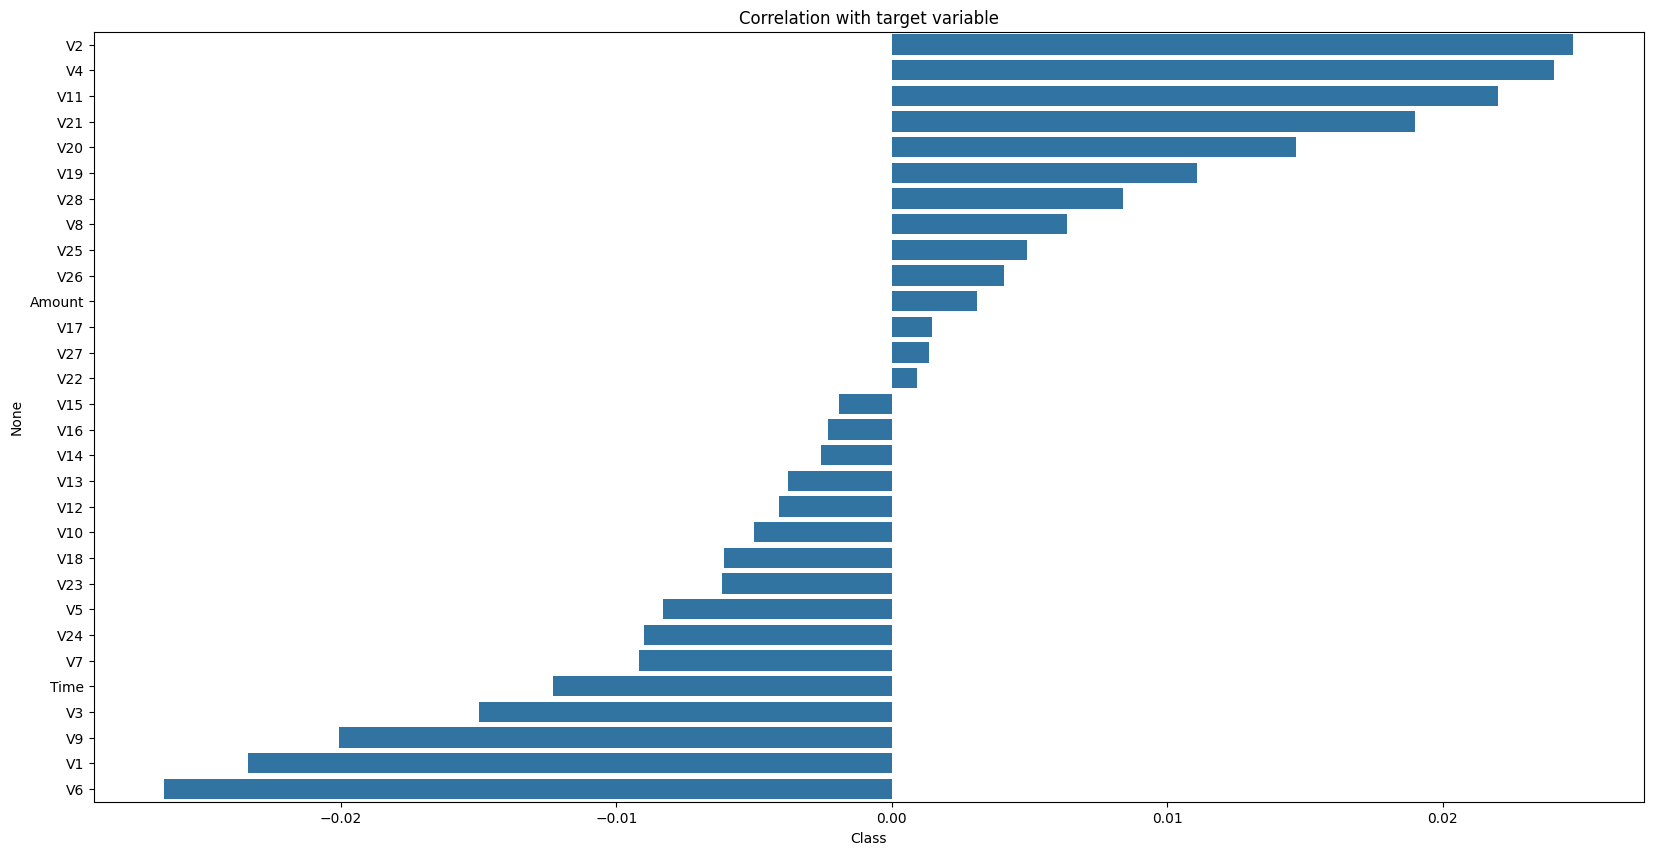

In [20]:
corr_with_target = df_transformed[NO_TARGET_NAMES + ['Amount'] + ['Class']].corr().iloc[:-1, -1].sort_values(ascending=False)

sns.barplot(x=corr_with_target, y=corr_with_target.index)
plt.title('Correlation with target variable')
plt.show()

- As we can see, the higher correlation with target have such features as V2, V4 (positive correlation) and V1, V6 (negative correlation).  
- Amount feature has low positive correlation with target, also proving our thesis that high amount transactions should not be automatically considered as fraud.

## Analysing whether Amount feature is relevant for the analysis

Since we see that Amount column has low correlation with target, let's explore whether we can statistically prove that Amount of transaction  is statistically significant in the fraud analysis.

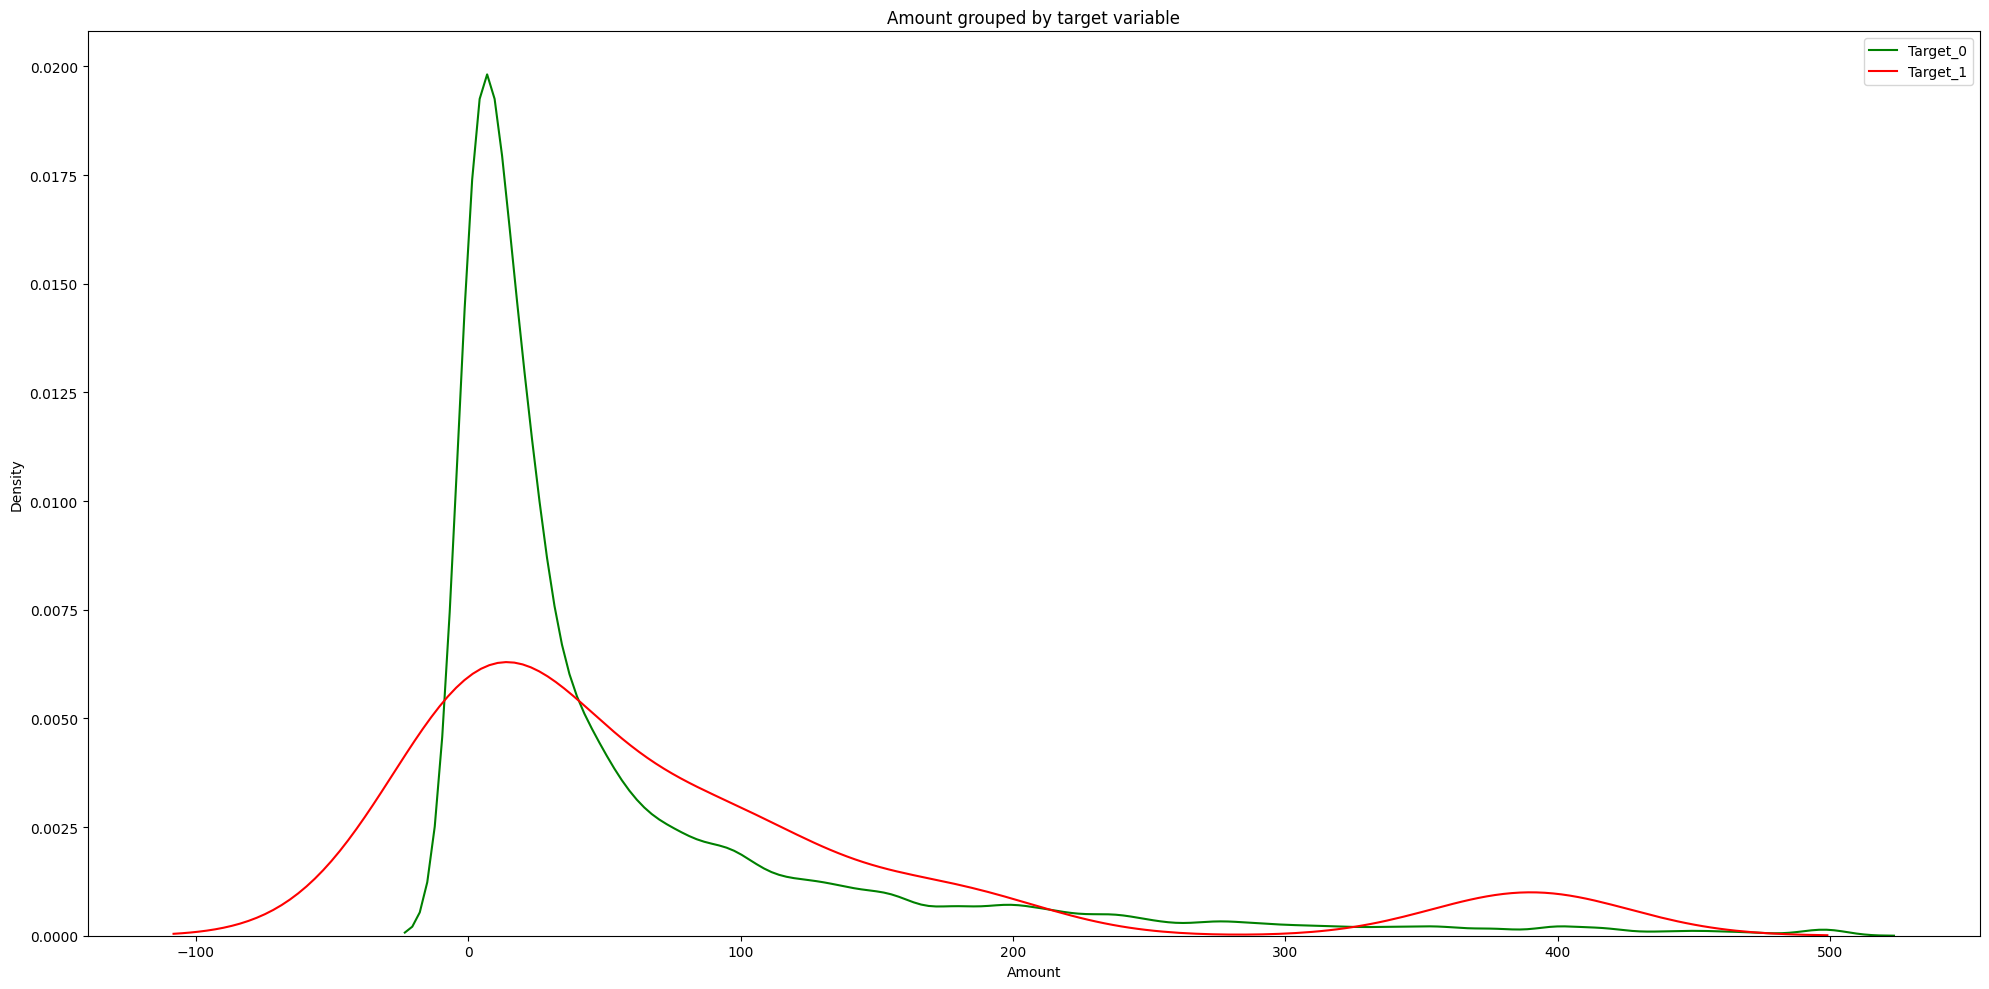

In [25]:
TARGET_NAME='Class'

amt_with_target = df_transformed[['Amount', TARGET_NAME]].sample(5000)

amt_with_target_s = amt_with_target['Amount']

amt_target_0 = amt_with_target_s[amt_with_target[TARGET_NAME]==0]
amt_target_1 = amt_with_target_s[amt_with_target[TARGET_NAME]==1]

sns.kdeplot(amt_target_0,  color='g', label='Target_0',bw_adjust=.5)
sns.kdeplot(amt_target_1,  color='r', label='Target_1',bw_adjust=.5)

plt.legend()

plt.title('Amount grouped by target variable')
plt.tight_layout()
plt.show()

In [26]:
shapiro(amt_with_target_s)

ShapiroResult(statistic=np.float64(0.6635803200673286), pvalue=np.float64(8.144724331133589e-72))

Shapiro test. P value < 0.05, so sample (Amount) is not normally distributed.  
We can also prove it graphically using probability and distribution plots.

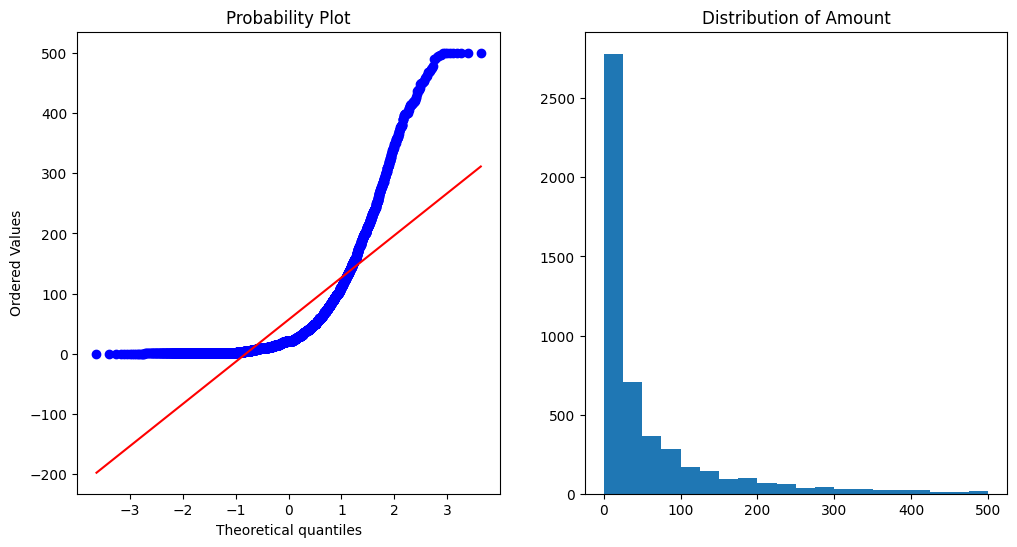

In [27]:

rcParams['figure.figsize'] = 12, 6

ax1 = plt.subplot(121)
probplot(amt_with_target_s, dist='norm', plot=plt)

ax2 = plt.subplot(122)
ax2.set_title('Distribution of Amount')
plt.hist(amt_with_target_s, bins=20)

plt.show()

Let's use Mann Whitney test (a non-parametric statistical test used to compare differences between two independent groups when the dependent variable is ordinal or continuous but not normally distributed) on samples Amount-Target-0 and Amount-Target-1 to see if they are statistically different.

In [28]:
mannwhitneyu(amt_target_0, amt_target_1)

MannwhitneyuResult(statistic=np.float64(26677.0), pvalue=np.float64(0.8733912106224966))

Pvalue > 0.05, it means that distributions are statistically different. Thus, Amount feature is statistically significant in our analysis.

## Correlation among the features

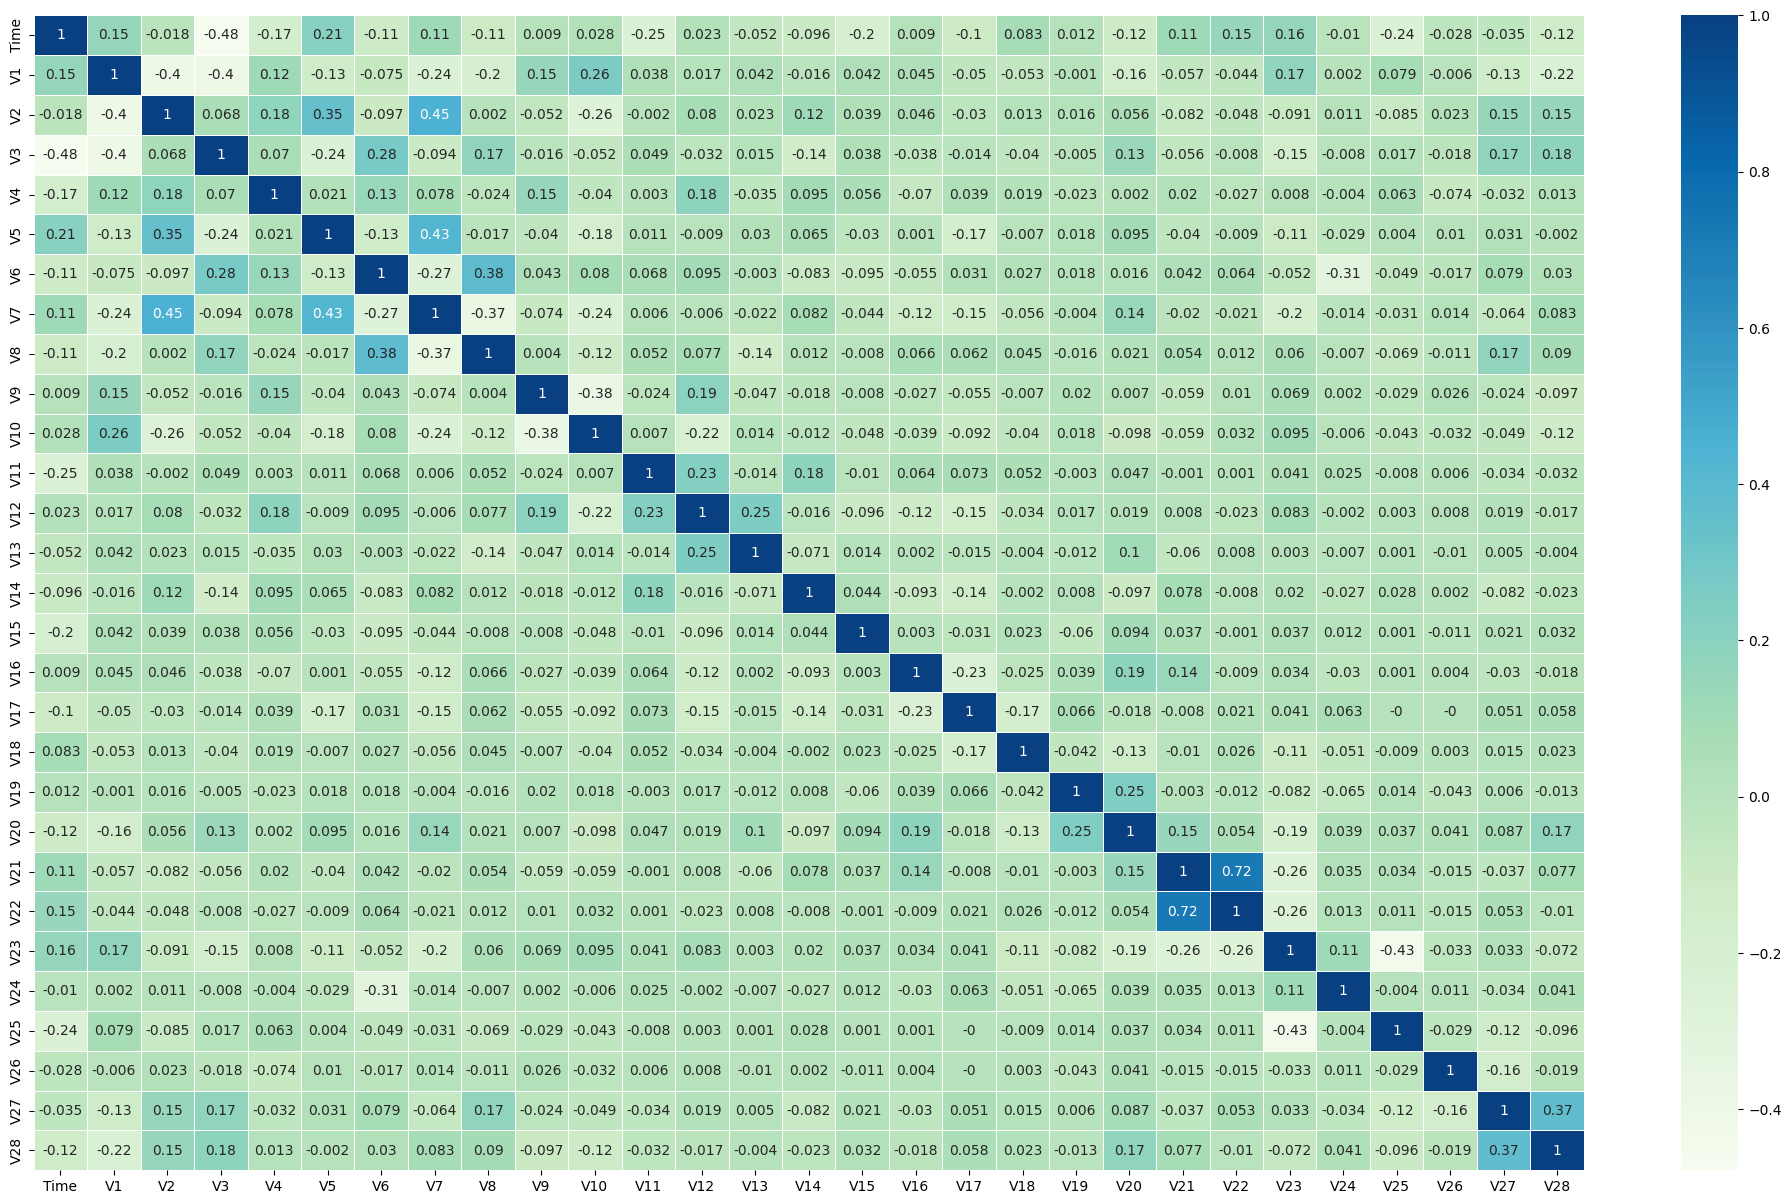

In [29]:
rcParams['figure.figsize'] = 25, 15

sns.heatmap(df_transformed[NO_TARGET_NAMES].corr().round(3), annot=True, cmap='GnBu', linewidth=0.5)
plt.show()

We see one high correlation 0.72 between V21 and V22. However we will not remove neither of these variables, since we do not know their nature and it is the only case in the entire dataset with high correlation, so it will not impact analysis.

The next step is preprocessing train and test datasets.